# 09 – Word2Vec, LSTM y CNN para detección de cambio de autor

En esta fase armamos un cuaderno espejo del 08, pero ahora probamos representaciones densas y prototipos neuronales ligeros. Trabajamos con:

- Embeddings estáticos Word2Vec entrenados en la E2.
- Embeddings contextuales (DistilBERT) precalculados.
- Deltas por frontera más secuencias pequeñas para alimentar MLP, LSTM y una CNN 1D.

El foco es exploratorio: separamos todo el cómputo pesado en scripts externos para no colgar el kernel del MacBook M1 Pro.

## 0. Setup
Definimos rutas, helpers y semillas reutilizando los mismos patrones del Notebook 08.

In [1]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def find_project_root(marker: str = ".git") -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError("No se encontró la raíz del proyecto")


def boundaries_to_segments(y_boundaries: np.ndarray) -> np.ndarray:
    y_boundaries = np.asarray(y_boundaries, dtype=int)
    n_sentences = len(y_boundaries) + 1
    segments = np.zeros(n_sentences, dtype=int)
    current = 0
    segments[0] = current
    for i, val in enumerate(y_boundaries):
        if val:
            current += 1
        segments[i + 1] = current
    return segments


def pk(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference)
    hypothesis = np.asarray(hypothesis)
    if reference.shape != hypothesis.shape:
        raise ValueError("reference y hypothesis deben tener la misma longitud")
    if k <= 0 or len(reference) <= k:
        return 0.0
    disagreements = 0
    total = 0
    for i in range(len(reference) - k):
        same_ref = reference[i] == reference[i + k]
        same_hyp = hypothesis[i] == hypothesis[i + k]
        disagreements += int(same_ref != same_hyp)
        total += 1
    return disagreements / total if total else 0.0


def windowdiff(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference, dtype=int)
    hypothesis = np.asarray(hypothesis, dtype=int)
    if reference.shape != hypothesis.shape:
        raise ValueError("reference y hypothesis deben tener la misma longitud")
    n_sentences = len(reference) + 1
    if k <= 0 or n_sentences <= k:
        return 0.0
    total = n_sentences - k
    errors = 0
    for start in range(total):
        end = start + k - 1
        ref_count = reference[start:end].sum()
        hyp_count = hypothesis[start:end].sum()
        errors += int(ref_count != hyp_count)
    return errors / total if total else 0.0


def evaluate_predictions(df_boundaries: pd.DataFrame, y_pred: np.ndarray) -> dict:
    df = df_boundaries.sort_values(["level", "doc_id", "boundary_id"]).reset_index(drop=True)
    y_true = df["y"].to_numpy().astype(int)
    y_pred = np.asarray(y_pred, dtype=int)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    doc_records = []
    seg_lengths = []
    for (_, _doc_id), group in df.groupby(["level", "doc_id"]):
        idx = group.index.to_numpy()
        y_doc = group["y"].to_numpy()
        doc_records.append((idx, y_doc))
        seg = boundaries_to_segments(y_doc)
        _, counts = np.unique(seg, return_counts=True)
        seg_lengths.extend(counts.tolist())
    mean_segment_length = float(np.mean(seg_lengths)) if seg_lengths else 1.0
    k = max(1, int(round(mean_segment_length / 2)))
    pk_scores = []
    wd_scores = []
    for idx, y_doc in doc_records:
        y_pred_doc = y_pred[idx]
        seg_true = boundaries_to_segments(y_doc)
        seg_pred = boundaries_to_segments(y_pred_doc)
        pk_scores.append(pk(seg_true, seg_pred, k=k))
        wd_scores.append(windowdiff(y_doc, y_pred_doc, k=k))
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "pk": float(np.mean(pk_scores)) if pk_scores else np.nan,
        "windowdiff": float(np.mean(wd_scores)) if wd_scores else np.nan,
        "k_window": k,
    }


PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
BOUNDARIES_DIR = DATA_PROCESSED / "boundaries"
FEATURES_DIR = PROJECT_ROOT / "features"
W2V_DIR = FEATURES_DIR / "word2vec"
if not W2V_DIR.exists():
    W2V_DIR = FEATURES_DIR / "embeddings_static"
BERT_DIR = FEATURES_DIR / "contextual"
if not BERT_DIR.exists():
    BERT_DIR = FEATURES_DIR / "embeddings_contextual"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("W2V_DIR:", W2V_DIR)
print("BERT_DIR:", BERT_DIR)


PROJECT_ROOT: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis
W2V_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/features/embeddings_static
BERT_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/features/embeddings_contextual


## 1. Carga de datos
Igual que en el Notebook 07/08, trabajamos con el dataset de fronteras (`boundaries_train.csv` / `boundaries_validation.csv`).

In [2]:
boundaries_train = pd.read_csv(BOUNDARIES_DIR / "boundaries_train.csv")
boundaries_val = pd.read_csv(BOUNDARIES_DIR / "boundaries_validation.csv")

print(f"train: {len(boundaries_train):,} fronteras")
print(boundaries_train['y'].value_counts(normalize=True).rename('pct_train'))
print("-" * 40)
print(f"validation: {len(boundaries_val):,} fronteras")
print(boundaries_val['y'].value_counts(normalize=True).rename('pct_val'))


train: 159,002 fronteras
y
0    0.809474
1    0.190526
Name: pct_train, dtype: float64
----------------------------------------
validation: 33,858 fronteras
y
0    0.806013
1    0.193987
Name: pct_val, dtype: float64


## 2. Construcción de índices y alineamiento
Necesitamos los índices de oración que generamos para mapear cada `sent_id` a la fila correspondiente en las matrices de embeddings.

In [3]:
idx_w2v_train = pd.read_csv(W2V_DIR / "S_train_index.csv").head()
idx_bert_train = pd.read_csv(BERT_DIR / "C_train_index.csv").head()
print("Word2Vec index sample:")
print(idx_w2v_train)
print("DistilBERT index sample:")
print(idx_bert_train)

Word2Vec index sample:
  level  split     doc_id  sent_id
0  easy  train  problem-1        0
1  easy  train  problem-1        1
2  easy  train  problem-1        2
3  easy  train  problem-1        3
4  easy  train  problem-1        4
DistilBERT index sample:
  level  split     doc_id  sent_id
0  easy  train  problem-1        0
1  easy  train  problem-1        1
2  easy  train  problem-1        2
3  easy  train  problem-1        3
4  easy  train  problem-1        4


## 3. Construcción de embeddings (Word2Vec / BERT)
Trabajamos con las matrices ya calculadas anteriormente. Hacemos un repaso rápido para verificar dimensiones y distribuciones.

Word2Vec train shape: (171602, 128)


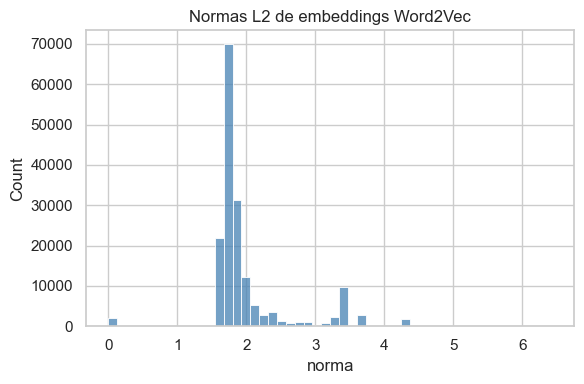

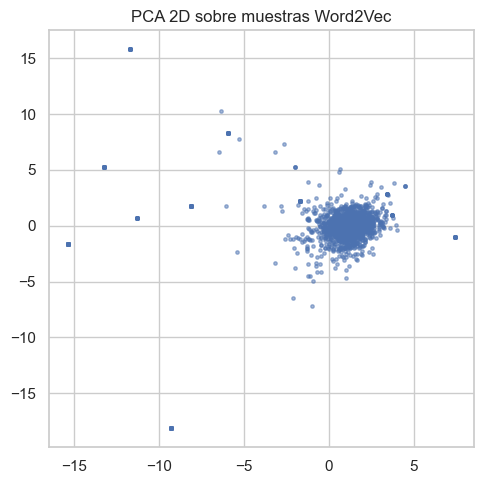

In [4]:
try:
    w2v_train = np.load(W2V_DIR / "S_train.npy")
    w2v_val = np.load(W2V_DIR / "S_validation.npy")
    print("Word2Vec train shape:", w2v_train.shape)
    norms = np.linalg.norm(w2v_train, axis=1)
    plt.figure(figsize=(6, 4))
    sns.histplot(norms, bins=50, color="steelblue")
    plt.title("Normas L2 de embeddings Word2Vec")
    plt.xlabel("norma")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "09_w2v_norm_hist.png", dpi=150)
    plt.show()

    sample = np.random.choice(w2v_train.shape[0], size=2000, replace=False)
    scaler = StandardScaler()
    pca = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(scaler.fit_transform(w2v_train[sample]))
    plt.figure(figsize=(5, 5))
    plt.scatter(proj[:, 0], proj[:, 1], s=6, alpha=0.5)
    plt.title("PCA 2D sobre muestras Word2Vec")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "09_w2v_pca.png", dpi=150)
    plt.show()

    del w2v_train
    del w2v_val
except FileNotFoundError as exc:
    print("No encontré embeddings Word2Vec:", exc)


DistilBERT train shape: (171602, 768)


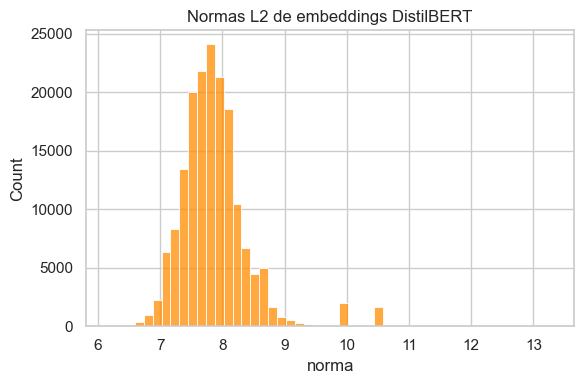

In [5]:
try:
    bert_train = np.load(BERT_DIR / "C_train.npy")
    bert_val = np.load(BERT_DIR / "C_validation.npy")
    print("DistilBERT train shape:", bert_train.shape)
    norms = np.linalg.norm(bert_train, axis=1)
    plt.figure(figsize=(6, 4))
    sns.histplot(norms, bins=50, color="darkorange")
    plt.title("Normas L2 de embeddings DistilBERT")
    plt.xlabel("norma")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "09_bert_norm_hist.png", dpi=150)
    plt.show()

    del bert_train
    del bert_val
except FileNotFoundError as exc:
    print("No encontré embeddings DistilBERT:", exc)


## 4. Construcción de matrices delta (por frontera)
Para no repetir cálculos pesados en el notebook, delegamos el preprocesamiento al script `scripts/09/09_compute_deltas.py`. Este script:

1. Carga `boundaries_*` y los embeddings de frases (Word2Vec / DistilBERT).
2. Calcula deltas simples (`emb_right - emb_left`) para cada frontera.
3. Construye secuencias cortas alrededor de la frontera con DistilBERT para las redes (LSTM / CNN).
4. Guarda todo en `data/processed/` para que el notebook solo tenga que leer los resultados.

In [6]:
delta_paths = {
    "w2v_train": DATA_PROCESSED / "delta_w2v_train.parquet",
    "w2v_val": DATA_PROCESSED / "delta_w2v_val.parquet",
    "bert_train": DATA_PROCESSED / "delta_bert_train.parquet",
    "bert_val": DATA_PROCESSED / "delta_bert_val.parquet",
}

delta_w2v_train = pd.read_parquet(delta_paths["w2v_train"]) if delta_paths["w2v_train"].exists() else None
if delta_w2v_train is not None:
    print(delta_w2v_train.shape)
    display(delta_w2v_train.head())
else:
    print("No se encontraron los archivos delta. Ejecuta el script anterior.")


(159002, 129)


,w2v_f0000,w2v_f0001,w2v_f0002,w2v_f0003,w2v_f0004,w2v_f0005,w2v_f0006,w2v_f0007,w2v_f0008,w2v_f0009,...,w2v_f0119,w2v_f0120,w2v_f0121,w2v_f0122,w2v_f0123,w2v_f0124,w2v_f0125,w2v_f0126,w2v_f0127,y
0,-0.040918,-0.053480,-0.057845,0.100449,-0.004300,0.012769,-0.071780,-0.003272,0.121127,-0.002080,...,-0.093868,-0.011545,-0.020566,0.007712,-0.029318,0.013775,0.090319,0.092695,0.046224,0
1,0.017437,0.033608,0.002031,-0.026490,0.024576,0.068381,0.150459,0.098009,-0.033394,0.021918,...,-0.058983,0.016018,-0.050858,-0.059733,0.016096,0.019826,-0.088165,-0.059598,0.002595,0
2,0.160544,-0.008118,0.201895,-0.076375,-0.060850,0.108506,-0.019594,-0.155076,-0.045225,0.003985,...,0.052556,0.191080,0.030571,0.016793,-0.141002,-0.172561,0.050702,-0.110826,0.007857,0
3,-0.071428,0.045093,-0.235905,-0.080139,0.041811,-0.176983,-0.074678,0.035917,-0.164829,-0.129849,...,-0.016490,-0.142700,0.016930,-0.025907,0.123639,0.248533,-0.027993,0.157973,0.130581,0
4,-0.065929,-0.052834,0.059318,0.120145,0.035441,0.119517,0.047525,0.106300,0.181986,0.032392,...,0.114632,-0.001469,0.041558,0.054035,0.000980,-0.084472,0.051225,0.025378,-0.148958,0


## 5. Modelos clásicos (LogReg / SVM / MLP simple)
Para estos modelos solo necesitamos los deltas densos, así que también los entrenamos fuera del notebook.

```
python scripts 09_train_models.py --epochs 3 --batch-size 64
```

Ese script entrena `LogisticRegression`, `LinearSVC` y un MLP chiquito sobre los deltas Word2Vec y guarda todo en `reports/09_metrics.json`. Aquí solo cargamos las métricas para compararlas.

In [7]:
metrics_path = REPORTS_DIR / "09_metrics.json"
metrics_09 = {}
if metrics_path.exists():
    metrics_09 = json.loads(metrics_path.read_text())
    classic_labels = ["w2v_logreg", "w2v_svm", "w2v_mlp"]
    rows = []
    for label in classic_labels:
        if label in metrics_09:
            row = {"label": label}
            row.update(metrics_09[label]["metrics_val"])
            rows.append(row)
    if rows:
        display(pd.DataFrame(rows))
    else:
        print("Aún no hay resultados clásicos en el JSON.")
else:
    print("No se encontró reports/09_metrics.json. Corre el script de entrenamiento.")


,label,accuracy,f1_macro,pk,windowdiff,k_window
0,w2v_logreg,0.630457,0.527246,0.507347,0.369016,2
1,w2v_svm,0.642153,0.532388,0.497750,0.359344,2
2,w2v_mlp,0.818123,0.537253,0.367678,0.208664,2


### ***6. Modelos profundos (MLP / LSTM / CNN)***
El mismo `09_train_models.py` también entrena:

- Un MLP de dos capas sobre deltas DistilBERT.
- Un LSTM de una capa sobre secuencias cortas (half-window = 2 → secuencia de 4 embeddings).
- Una CNN 1D muy pequeña con kernels 3 y 5, seguida de MaxPooling y capa final binaria.

In [8]:
if metrics_09:
    neural_labels = ["bert_mlp", "bert_lstm", "bert_cnn"]
    rows = []
    for label in neural_labels:
        if label in metrics_09:
            row = {"label": label}
            row.update(metrics_09[label]["metrics_val"])
            rows.append(row)
    if rows:
        display(pd.DataFrame(rows))
    else:
        print("Todavía no hay resultados neuronales en el JSON.")
else:
    print("Carga primero el JSON de métricas en la sección anterior.")


,label,accuracy,f1_macro,pk,windowdiff,k_window
0,bert_mlp,0.818861,0.539617,0.365526,0.208122,2
1,bert_lstm,0.859561,0.706384,0.254031,0.162597,2
2,bert_cnn,0.858291,0.707705,0.255501,0.163812,2


### ***7. Tabla resumen final***
Combinamos los baselines (`never_change`, `random_p_train`), el mejor modelo lineal TF-IDF del Notebook 08 y los prototipos de este Notebook. Ordenamos por `f1_macro` en validación para ver rápidamente qué aporta cada bloque.

In [9]:
summary_rows = []

# Baseline: nunca colocar frontera
summary_rows.append({"label": "never_change", **evaluate_predictions(boundaries_val, np.zeros(len(boundaries_val), dtype=int))})

# Baseline aleatorio calibrado con train
rng = np.random.default_rng(SEED)
p_change = boundaries_train["y"].mean()
random_preds = (rng.random(len(boundaries_val)) < p_change).astype(int)
summary_rows.append({"label": "random_p_train", **evaluate_predictions(boundaries_val, random_preds)})

# tfidf_svm del Notebook 08
svm08_path = REPORTS_DIR / "08_svm_metrics.json"
if svm08_path.exists():
    svm08 = json.loads(svm08_path.read_text())
    row = {"label": "tfidf_svm"}
    row.update(svm08["metrics_val"])
    summary_rows.append(row)
else:
    print("No encontré reports/08_svm_metrics.json; salteando tfidf_svm.")

# Modelos de este notebook
wanted_labels = [
    "w2v_logreg",
    "w2v_svm",
    "w2v_mlp",
    "bert_mlp",
    "bert_lstm",
    "bert_cnn",
]
for label in wanted_labels:
    if label in metrics_09:
        row = {"label": label}
        row.update(metrics_09[label]["metrics_val"])
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df.sort_values("f1_macro", ascending=False)
    display(summary_df)
else:
    print("No hay filas para la tabla resumen todavía.")


,label,accuracy,f1_macro,pk,windowdiff,k_window
8,bert_cnn,0.858291,0.707705,0.255501,0.163812,2
7,bert_lstm,0.859561,0.706384,0.254031,0.162597,2
2,tfidf_svm,0.735897,0.544605,0.432065,0.281982,2
6,bert_mlp,0.818861,0.539617,0.365526,0.208122,2
5,w2v_mlp,0.818123,0.537253,0.367678,0.208664,2
4,w2v_svm,0.642153,0.532388,0.497750,0.359344,2
3,w2v_logreg,0.630457,0.527246,0.507347,0.369016,2
1,random_p_train,0.692244,0.503895,0.460828,0.329491,2
0,never_change,0.806013,0.446294,0.400211,0.227808,2
